# Cuaderno extra: Recuperación y preprocesamiento de imágenes propias

Este cuaderno está pensado para trabajar con una imagen tomada por vos, por ejemplo una captura hecha a partir de la cámara oscura construida con caja de zapatos y bolsa. La idea es recuperar información útil antes de segmentar: mejorar contraste, corregir brillo, recortar la zona importante y reducir ruido.

## Objetivos

- Cargar una imagen propia y describirla.
- Detectar qué problema visual conviene corregir primero.
- Aplicar una o dos operaciones de preprocesamiento con criterio.
- Comparar la imagen original con la versión mejorada.
- Guardar una imagen lista para usar en la actividad integradora.

## Antes de empezar

No todas las imágenes necesitan el mismo tratamiento. En algunas puede convenir mejorar el contraste. En otras, recortar la zona útil. En otras, reducir ruido o corregir una dominante de iluminación.

La pregunta importante no es "qué filtro aplico", sino "qué problema veo en la imagen y qué operación puede ayudarme a resolverlo".

In [1]:
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np


def cargar_rgb(ruta):
    imagen_bgr = cv2.imread(str(ruta))
    if imagen_bgr is None:
        raise FileNotFoundError(f"No se pudo abrir la imagen: {ruta}")
    return cv2.cvtColor(imagen_bgr, cv2.COLOR_BGR2RGB)


def mostrar_imagen(imagen, titulo="Imagen"):
    plt.figure(figsize=(6, 6))
    plt.imshow(imagen, cmap="gray" if imagen.ndim == 2 else None)
    plt.title(titulo)
    plt.axis("off")
    plt.show()


def mostrar_comparacion(original, procesada, titulo_original="Original", titulo_procesada="Procesada"):
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    axes[0].imshow(original, cmap="gray" if original.ndim == 2 else None)
    axes[0].set_title(titulo_original)
    axes[0].axis("off")

    axes[1].imshow(procesada, cmap="gray" if procesada.ndim == 2 else None)
    axes[1].set_title(titulo_procesada)
    axes[1].axis("off")

    plt.tight_layout()
    plt.show()


def ajustar_brillo_contraste(imagen_rgb, alpha=1.2, beta=10):
    return cv2.convertScaleAbs(imagen_rgb, alpha=alpha, beta=beta)


def suavizar(imagen_rgb, kernel=5):
    return cv2.GaussianBlur(imagen_rgb, (kernel, kernel), 0)


def mejorar_contraste_clahe(imagen_rgb, clip_limit=2.0, tile=8):
    imagen_lab = cv2.cvtColor(imagen_rgb, cv2.COLOR_RGB2LAB)
    l, a, b = cv2.split(imagen_lab)
    clahe = cv2.createCLAHE(clipLimit=clip_limit, tileGridSize=(tile, tile))
    l_mejorado = clahe.apply(l)
    imagen_lab_mejorada = cv2.merge((l_mejorado, a, b))
    return cv2.cvtColor(imagen_lab_mejorada, cv2.COLOR_LAB2RGB)


def mostrar_histograma_gris(imagen_rgb):
    gris = cv2.cvtColor(imagen_rgb, cv2.COLOR_RGB2GRAY)
    hist, bins = np.histogram(gris.flatten(), bins=256, range=[0, 256])
    plt.figure(figsize=(10, 4))
    plt.plot(bins[:-1], hist, color="black")
    plt.title("Histograma en escala de grises")
    plt.xlabel("Intensidad")
    plt.ylabel("Cantidad de píxeles")
    plt.grid(alpha=0.3)
    plt.xlim(0, 255)
    plt.show()

## Parte 1. Cargá tu imagen

Guardá tu archivo en la misma carpeta del notebook o escribí la ruta completa. Si tu imagen viene de la experiencia con cámara oscura, conviene elegir una captura donde todavía se reconozca bien la escena, aunque tenga poco contraste o zonas oscuras.

Archivo cargado: edificio.jpg
Forma: (4000, 3000, 3)
Tipo de dato: uint8


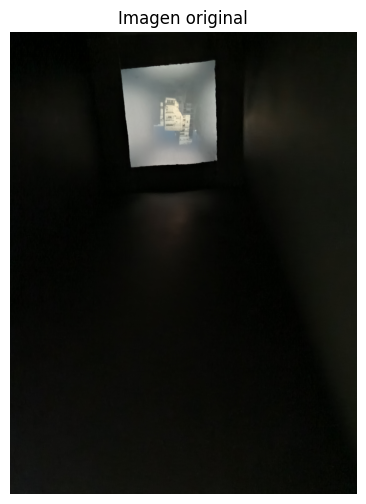

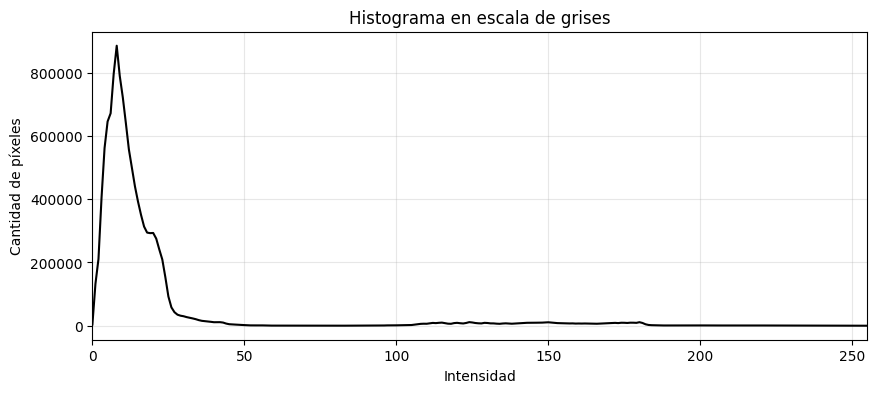

In [2]:
nombre_imagen = "edificio.jpg"
ruta = Path(nombre_imagen)

imagen_original = cargar_rgb(ruta)

print(f"Archivo cargado: {ruta}")
print(f"Forma: {imagen_original.shape}")
print(f"Tipo de dato: {imagen_original.dtype}")

mostrar_imagen(imagen_original, "Imagen original")
mostrar_histograma_gris(imagen_original)

## Parte 2. Diagnóstico inicial

Escribí qué problema principal ves en la imagen. Algunas posibilidades:

- se ve demasiado oscura,
- está invertida (boca arriba),
- hay ruido,
- sobra mucho fondo y conviene recortar,
- la zona importante queda poco visible.

In [3]:
problema_principal = "zonas perifericas de la imagen muy oscura, imagen invertida"
hipotesis_mejora = "rotar 180°, redimensionar a 512x512, aplicar mejoras de contraste"

print("Problema principal:", problema_principal)
print("Operación que voy a probar primero:", hipotesis_mejora)

Problema principal: zonas perifericas de la imagen muy oscura, imagen invertida
Operación que voy a probar primero: rotar 180°, redimensionar a 512x512, aplicar mejoras de contraste


## Parte 3. Recorte opcional de la zona útil

Si la imagen tiene mucho fondo innecesario, podés recortar la región más importante antes de mejorarla. Si no necesitás recorte, dejá la imagen completa.

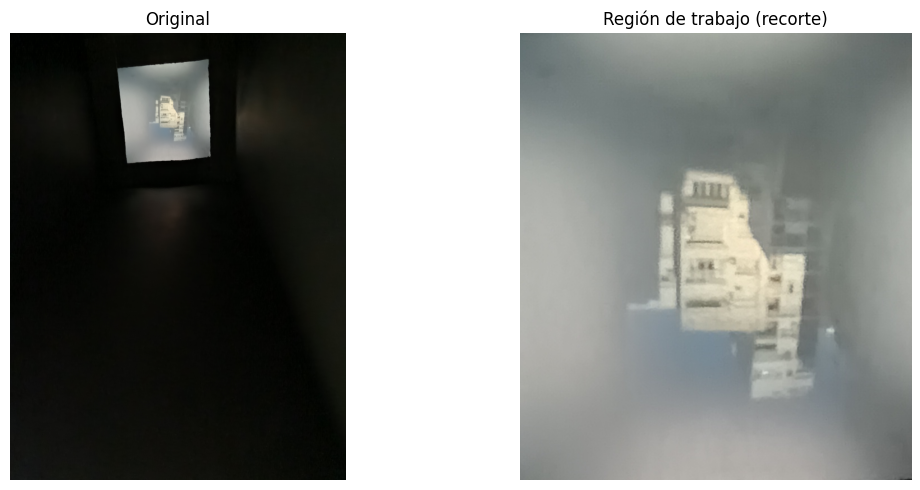

Forma: (800, 700, 3)
Tipo de dato: uint8


In [4]:
# Recortar zona central para enfocar la región más importante
y1, y2 = 320, 1120
x1, x2 = 1050, 1750

imagen_recortada = imagen_original[y1:y2, x1:x2]
mostrar_comparacion(imagen_original, imagen_recortada, "Original", "Región de trabajo (recorte)")
print(f"Forma: {imagen_recortada.shape}")
print(f"Tipo de dato: {imagen_recortada.dtype}")

## Parte 3b. Rotar, redimensionar y recortar la zona útil

Ahora vamos a: rotar la imagen 180° (porque está boca arriba), redimensionar a 512x512, para enfocarnos en la zona central de la cámara oscura.

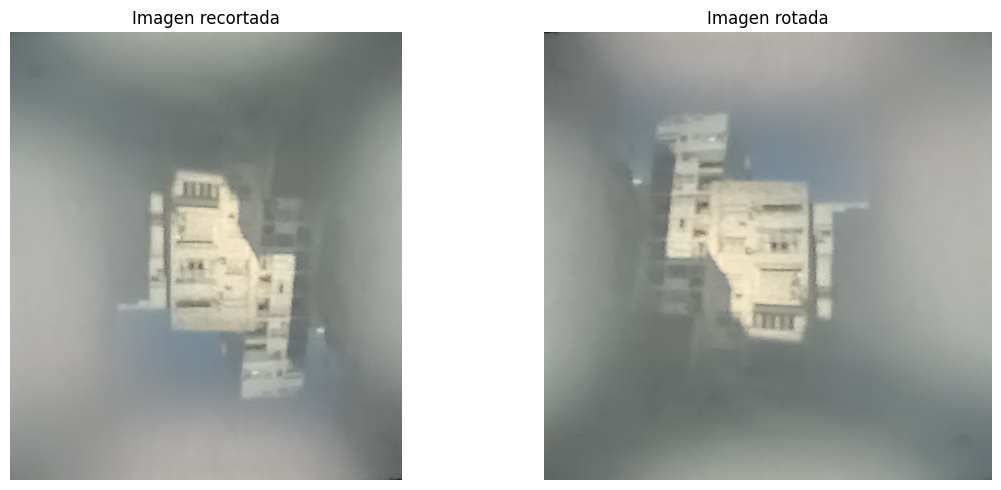

Forma Imagen rotada: (512, 512, 3)


In [8]:
# 1. Rotar la imagen 180 grados
imagen_rotada = cv2.rotate(imagen_recortada, cv2.ROTATE_180)

# 2. Redimensionar a 512x512
imagen_final = cv2.resize(imagen_rotada, (512, 512))
#imagen_512
# 3. Recortar ~100 píxeles de la izquierda (ajustable)
#recorte_derecha = 50
#imagen_final = imagen_512[:,:- recorte_derecha:]

# Redimensionar de nuevo para mantener 512x512
#imagen_final = cv2.resize(imagen_final, (512, 512))

mostrar_comparacion(imagen_recortada, imagen_final,"Imagen recortada" ,"Imagen rotada")
print(f"Forma Imagen rotada: {imagen_final.shape}")

## Parte 4. Probá mejoras de preprocesamiento

Acá tenés tres operaciones posibles. No hace falta usar todas. La idea es que pruebes, compares y decidas cuál te sirve más para preparar la imagen.

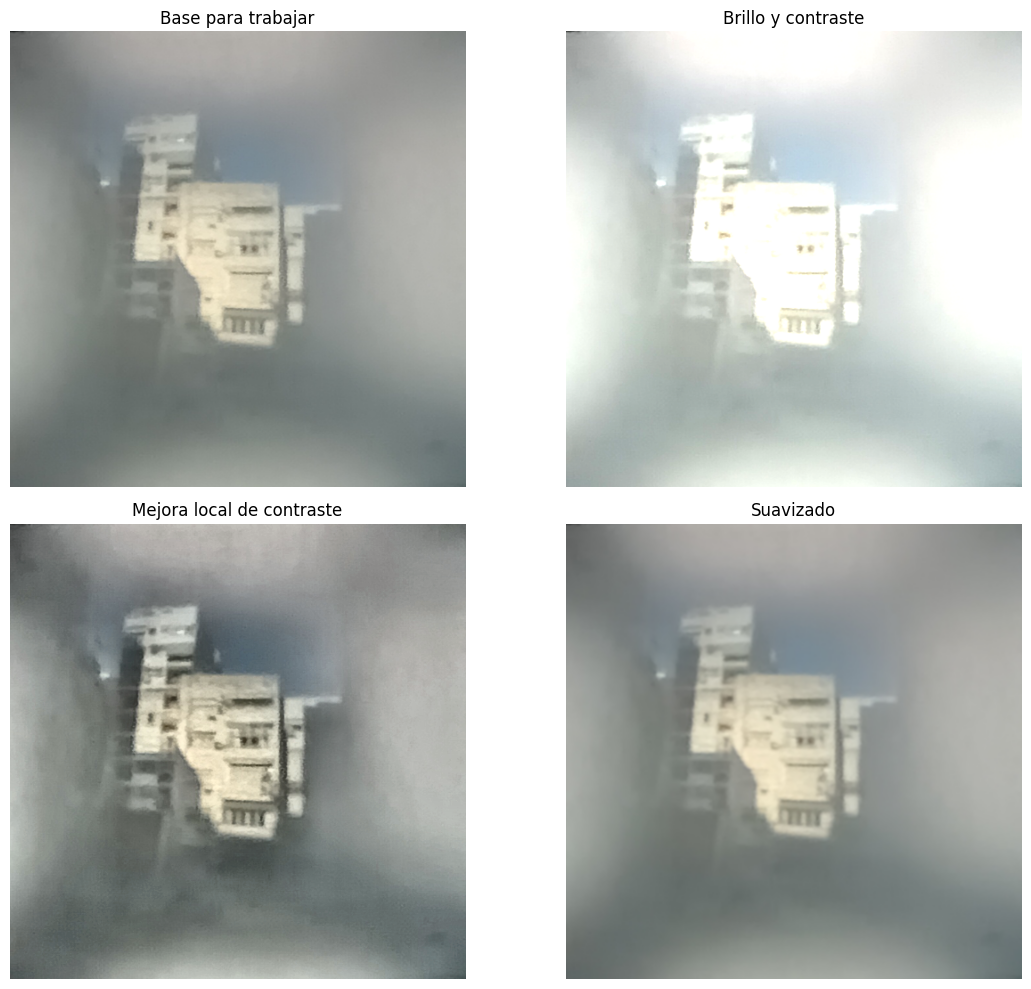

In [9]:
brillo_contraste = ajustar_brillo_contraste(imagen_final, alpha=1.4, beta=20)
clahe = mejorar_contraste_clahe(imagen_final, clip_limit=2.0, tile=8)
suavizada = suavizar(imagen_final, kernel=5)

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes[0, 0].imshow(imagen_final)
axes[0, 0].set_title("Base para trabajar")
axes[0, 0].axis("off")

axes[0, 1].imshow(brillo_contraste)
axes[0, 1].set_title("Brillo y contraste")
axes[0, 1].axis("off")

axes[1, 0].imshow(clahe)
axes[1, 0].set_title("Mejora local de contraste")
axes[1, 0].axis("off")

axes[1, 1].imshow(suavizada)
axes[1, 1].set_title("Suavizado")
axes[1, 1].axis("off")

plt.tight_layout()
plt.show()

## Parte 5. Elegí una versión final

Elegí cuál de las variantes te conviene conservar como imagen preprocesada. Si querés, también podés combinar operaciones en dos pasos, por ejemplo: primero mejorar contraste y después suavizar.

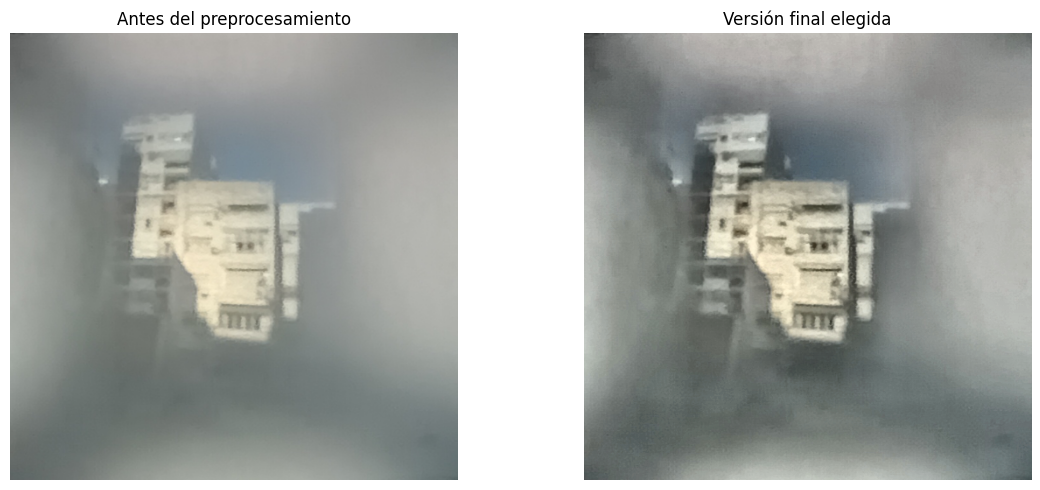

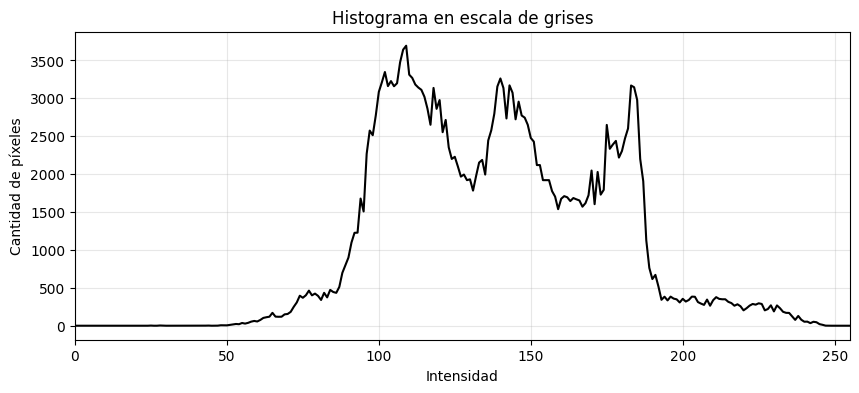

In [10]:
# Elegí una opción o combiná operaciones.
imagen_preprocesada = clahe

# Ejemplo de combinación posible:
# imagen_preprocesada = suavizar(ajustar_brillo_contraste(imagen_final, alpha=1.3, beta=15), kernel=5)

mostrar_comparacion(imagen_final, imagen_preprocesada, "Antes del preprocesamiento", "Versión final elegida")
mostrar_histograma_gris(imagen_preprocesada)

## Parte 6. Guardá el resultado para la actividad integradora

El objetivo es que el próximo cuaderno pueda tomar esta imagen como punto de partida.

In [11]:
salida = Path("imagen_preprocesada.png")
cv2.imwrite(str(salida), cv2.cvtColor(imagen_preprocesada, cv2.COLOR_RGB2BGR))
print(f"Imagen guardada en: {salida.resolve()}")

Imagen guardada en: E:\Doc\eduardo\tecprocesamientoImg\farfan-eduardo-pdi-1c-2026\004\003 - LAB\imagen_preprocesada.png


## Cierre escrito

Respondé con tus palabras:

1. ¿Qué problema principal tenía la imagen original?

La imagen original de cámara oscura estaba boca arriba (invertida), era muy grande (4000x3000) y tenía la zona perifericas muy oscura, con falta de detalle en las sombras. El histograma estaba desplazado hacia valores bajos.

2. ¿Qué operación u operaciones usaste para mejorarla?

Primero recorte la imagen para quedarme con el area de trabajo y enfocarme en la zona central de la cámara, luego roté la imagen 180° para corregir la orientación, tambien redimensioné a 512x512 para tener un tamaño estándar de trabajo. Finalmente apliqué CLAHE (Contrast Limited Adaptive Histogram Equalization) para mejorar el contraste local.

3. ¿Qué cambió entre la imagen original y la preprocesada?

La imagen preprocesada tiene orientación correcta, tamaño estándar (512x512), y mayor rango dinámico visible. El histograma se distribuye de forma más uniforme y las zonas oscuras ahora muestran detalle. Los objetos en las sombras son más visibles.

4. ¿Por qué pensás que esta nueva versión puede servir mejor para segmentar?

Porque al mejorar el contraste local con CLAHE, los objetos ahora tienen valores de intensidad diferenciables, lo que facilita la segmentación por color o umbral en el próximo paso. Además, el tamaño estándar 512x512 permite comparaciones consistentes con otras imágenes.

### Siguiente paso

Usá `imagen_preprocesada.png` en `008 - actividad integradora - segmentacion por color.ipynb` como imagen de entrada principal.

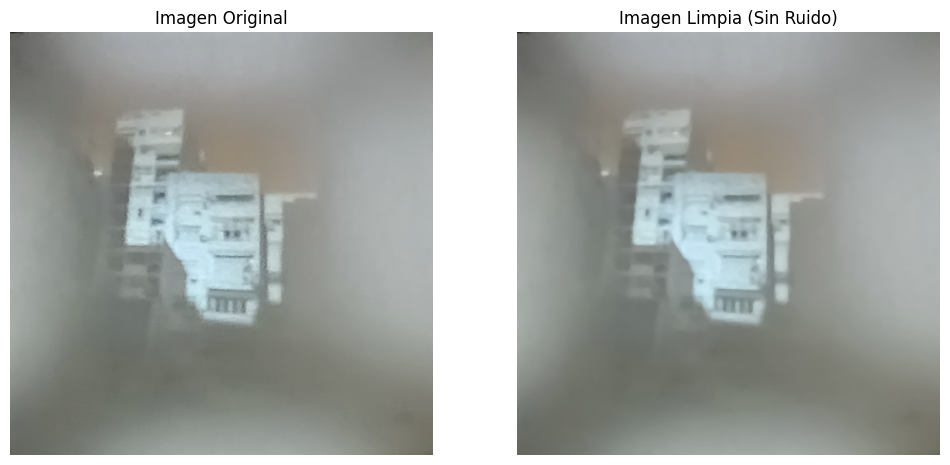

In [15]:
#import cv2
#import numpy as np
# Asegúrate de que 'imagen_final' es la imagen que quieres limpiar

def limpiar_ruido_sal_pimienta(imagen_final):
    """
    Aplica un filtro mediano para reducir el ruido de sal y pimienta.
    
    Args:
        imagen (np.array): La imagen de entrada (debe ser de escala de grises).
        
    Returns:
        np.array: La imagen limpia.
    """
    # El tamaño del kernel (el tamaño de la ventana de filtrado). 
    # Debe ser un número impar (ej. 3, 5, 7).
    kernel_size = 5 
    
    # Aplicar el filtro mediano
    imagen_limpia = cv2.medianBlur(imagen_final, kernel_size)
    
    return imagen_limpia

# --- Uso del código ---
# 1. Asegúrate de que la imagen esté en escala de grises (si no lo está)
imagen_gris = cv2.cvtColor(imagen_final, cv2.COLOR_BGR2GRAY)

# 2. Llama a la función para limpiar el ruido
imagen_sin_ruido = limpiar_ruido_sal_pimienta(imagen_final)

# 3. Visualizar el resultado (opcional)
#cv2.imshow("Imagen Original", imagen_final)
#cv2.imshow("Imagen Limpia", imagen_sin_ruido)
#cv2.waitKey(0)
#cv2.destroyAllWindows()

# Convertir las imágenes de BGR (OpenCV) a RGB (Matplotlib)
imagen_original_rgb = cv2.cvtColor(imagen_final, cv2.COLOR_BGR2RGB)
imagen_limpia_rgb = cv2.cvtColor(imagen_sin_ruido, cv2.COLOR_BGR2RGB)

# Mostrar ambas imágenes usando matplotlib
plt.figure(figsize=(12, 6))

# Mostrar la imagen original
plt.subplot(1, 2, 1)
plt.imshow(imagen_original_rgb)
plt.title("Imagen Original")
plt.axis("off")

# Mostrar la imagen limpia
plt.subplot(1, 2, 2)
plt.imshow(imagen_limpia_rgb)
plt.title("Imagen Limpia (Sin Ruido)")
plt.axis("off")

plt.show()